# Task 4 — Pick the right chart, five times (`mpg.csv`)

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":110,"axes.spines.top":False,"axes.spines.right":False,
                     "axes.titlesize":13,"axes.titleweight":"bold","axes.titlelocation":"left"})
NOTE = lambda fig, s: fig.text(0.01, -0.02, s, fontsize=9, color="dimgray", ha="left")   # exclusions / assumptions on the chart
df = pd.read_csv("mpg.csv")
df["year"] = np.where(df.model_year < 100, 1900 + df.model_year, df.model_year)
print(len(df), "cars; missing horsepower:", int(df.horsepower.isna().sum()), "(horsepower is not used in any chart below, so no cars are excluded)")

398 cars; missing horsepower: 6 (horsepower is not used in any chart below, so no cars are excluded)


## Q1. Did cars get more fuel-efficient between 1970 and 1982?

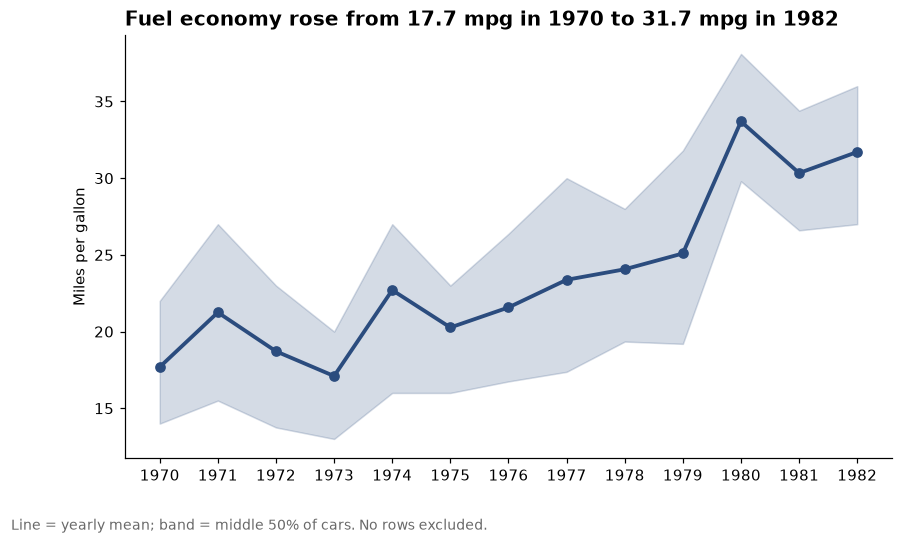

In [2]:
y = df.groupby("year").mpg.agg(mean="mean", q1=lambda s: s.quantile(.25), q3=lambda s: s.quantile(.75))
fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(y.index, y.q1, y.q3, color="#2b4c7e", alpha=0.2); ax.plot(y.index, y["mean"], color="#2b4c7e", lw=2.5, marker="o")
ax.set_ylabel("Miles per gallon"); ax.set_xticks(y.index)
ax.set_title(f"Fuel economy rose from {y['mean'].iloc[0]:.1f} mpg in {y.index[0]} to {y['mean'].iloc[-1]:.1f} mpg in {y.index[-1]}")
NOTE(fig, "Line = yearly mean; band = middle 50% of cars. No rows excluded."); plt.show()

**Line chart** with a spread band: the question is about change over time, and the band shows the typical car, not just the average.

## Q2. Do American, European and Japanese cars differ in fuel efficiency?

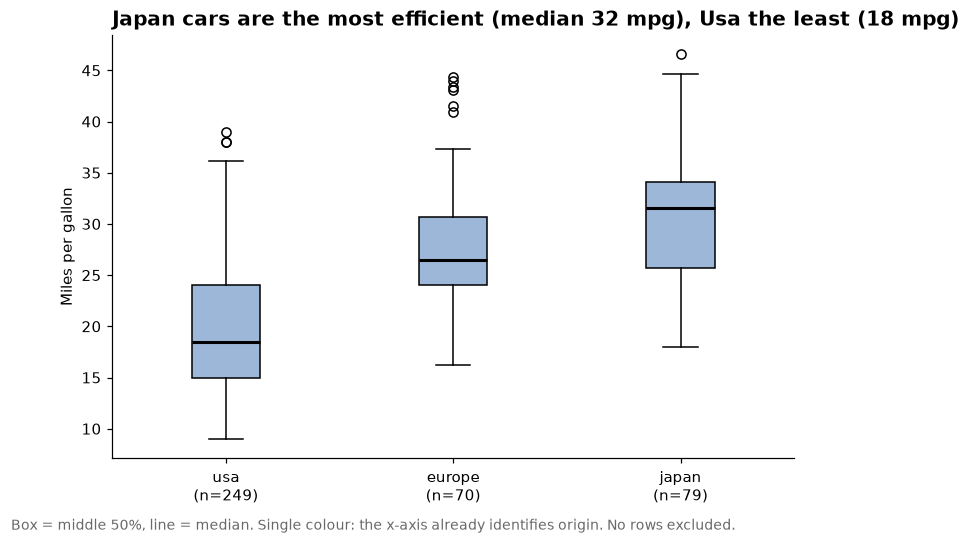

In [3]:
order = df.groupby("origin").mpg.median().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([df[df.origin==o].mpg for o in order], tick_labels=[f"{o}\n(n={int((df.origin==o).sum())})" for o in order], patch_artist=True,
           boxprops=dict(facecolor="#9db7d9"), medianprops=dict(color="black", lw=2))
ax.set_ylabel("Miles per gallon"); med = df.groupby("origin").mpg.median()
ax.set_title(f"{med.idxmax().title()} cars are the most efficient (median {med.max():.0f} mpg), {med.idxmin().title()} the least ({med.min():.0f} mpg)")
NOTE(fig, "Box = middle 50%, line = median. Single colour: the x-axis already identifies origin. No rows excluded."); plt.show()

**Box plot:** comparing a numeric variable across three groups needs distributions (median and spread), not just three averages.

## Q3. Relationship between weight and fuel efficiency (first version)

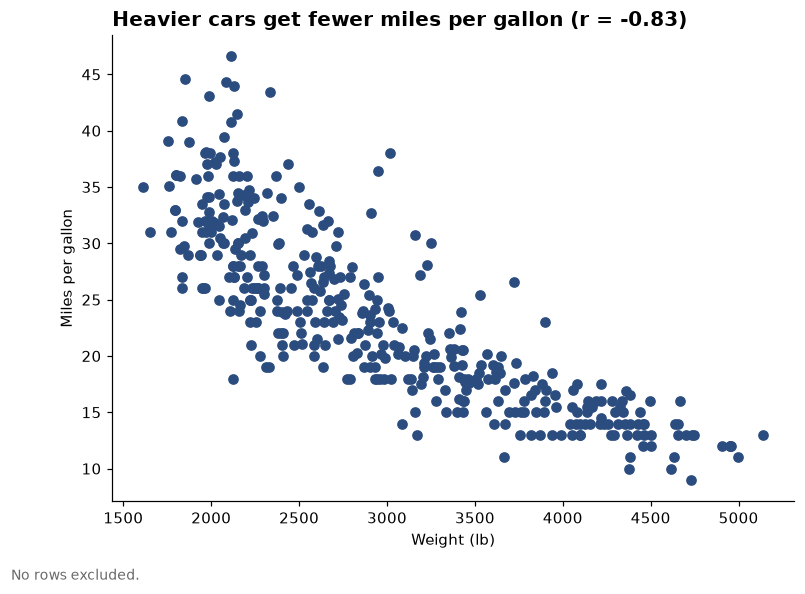

In [4]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(df.weight, df.mpg, color="#2b4c7e")
ax.set_xlabel("Weight (lb)"); ax.set_ylabel("Miles per gallon")
ax.set_title(f"Heavier cars get fewer miles per gallon (r = {df.weight.corr(df.mpg):.2f})")
NOTE(fig, "No rows excluded."); plt.show()

**Scatter plot:** two numeric variables, so the relationship is shown directly.

## Q4. How is the number of cylinders distributed?

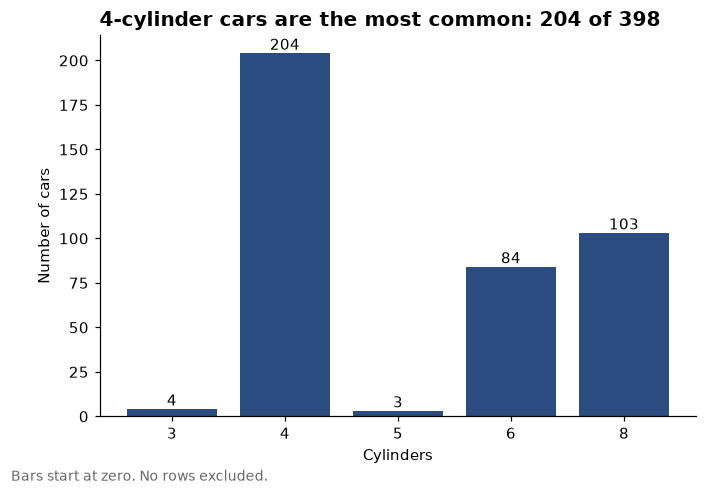

In [5]:
cnt = df.cylinders.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4.5)); bars = ax.bar(cnt.index.astype(str), cnt.values, color="#2b4c7e"); ax.bar_label(bars)
ax.set_xlabel("Cylinders"); ax.set_ylabel("Number of cars"); ax.set_ylim(0, None)
ax.set_title(f"{cnt.idxmax()}-cylinder cars are the most common: {cnt.max()} of {cnt.sum()}")
NOTE(fig, "Bars start at zero. No rows excluded."); plt.show()

**Bar chart:** cylinders take only a few discrete values, so counts per value (from zero) are the clearest distribution.

## Q5. Is the improvement in Q1 explained by Q3? (did cars get lighter?)

mpg gain 17.7->31.7; weight 3,373->2,454; share of gain predicted by weight alone: 50%
holding weight fixed, mpg still rises 0.76 per model year


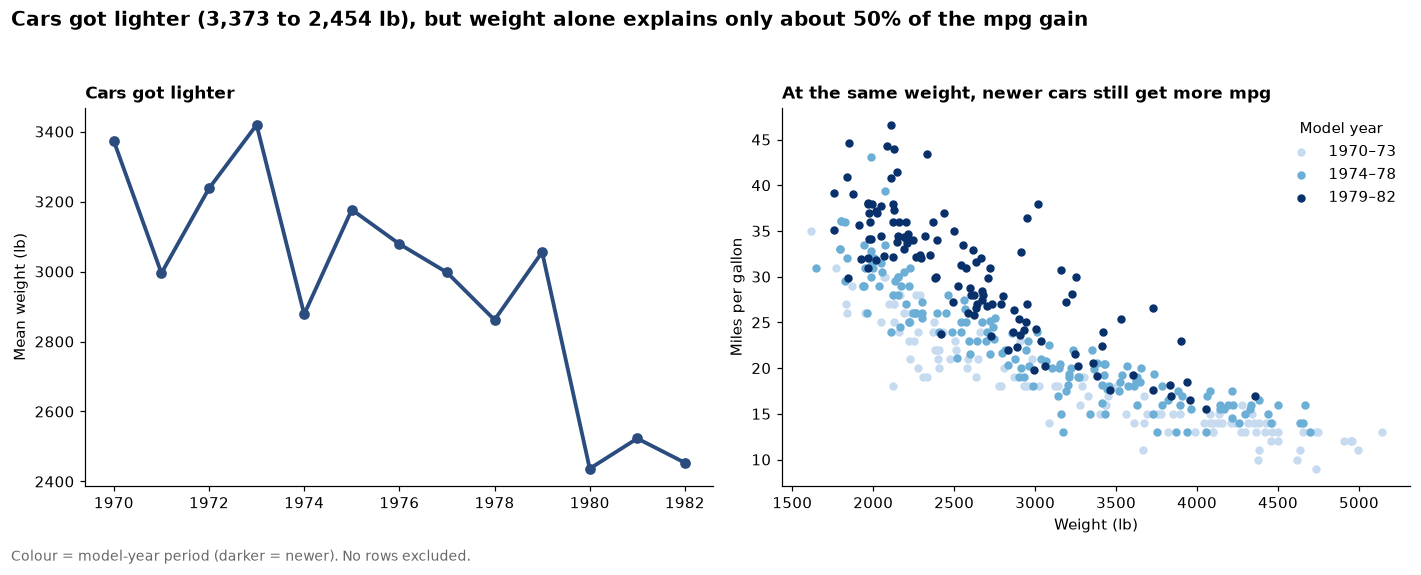

In [6]:
w = df.groupby("year").weight.mean(); m = df.groupby("year").mpg.mean()
slope = np.polyfit(df.weight, df.mpg, 1)[0]
share = slope*(w.iloc[-1]-w.iloc[0]) / (m.iloc[-1]-m.iloc[0])
X = np.column_stack([np.ones(len(df)), df.weight, df.year]); beta = np.linalg.lstsq(X, df.mpg, rcond=None)[0]
print(f"mpg gain {m.iloc[0]:.1f}->{m.iloc[-1]:.1f}; weight {w.iloc[0]:,.0f}->{w.iloc[-1]:,.0f}; share of gain predicted by weight alone: {share:.0%}")
print(f"holding weight fixed, mpg still rises {beta[2]:.2f} per model year")
fig, axs = plt.subplots(1, 2, figsize=(13, 5))
axs[0].plot(w.index, w.values, color="#2b4c7e", lw=2.5, marker="o"); axs[0].set_xticks(w.index[::2]); axs[0].set_ylabel("Mean weight (lb)"); axs[0].set_title("Cars got lighter", fontsize=11)
per = pd.cut(df.year, [1969, 1973, 1978, 1982], labels=["1970–73", "1974–78", "1979–82"])
for lab, col in zip(per.cat.categories, ["#c6dbef", "#6baed6", "#08306b"]):
    s = df[per == lab]; axs[1].scatter(s.weight, s.mpg, color=col, s=20, label=lab)
axs[1].legend(title="Model year", frameon=False); axs[1].set_xlabel("Weight (lb)"); axs[1].set_ylabel("Miles per gallon"); axs[1].set_title("At the same weight, newer cars still get more mpg", fontsize=11)
fig.suptitle(f"Cars got lighter ({w.iloc[0]:,.0f} to {w.iloc[-1]:,.0f} lb), but weight alone explains only about {share:.0%} of the mpg gain", x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0,0,1,0.94]); NOTE(fig, "Colour = model-year period (darker = newer). No rows excluded."); plt.show()

**Two panels (line + scatter coloured by period):** the line shows whether weight changed; the coloured scatter shows whether newer cars beat older cars *at the same weight*. If they do, weight does not fully explain the improvement.

## Weakest chart redrawn: Q3

**Weakness:** the points overlap heavily at the left and the relationship is curved, so a single correlation number in the title understates what the cloud shows, and the plot gives no summary of the trend.

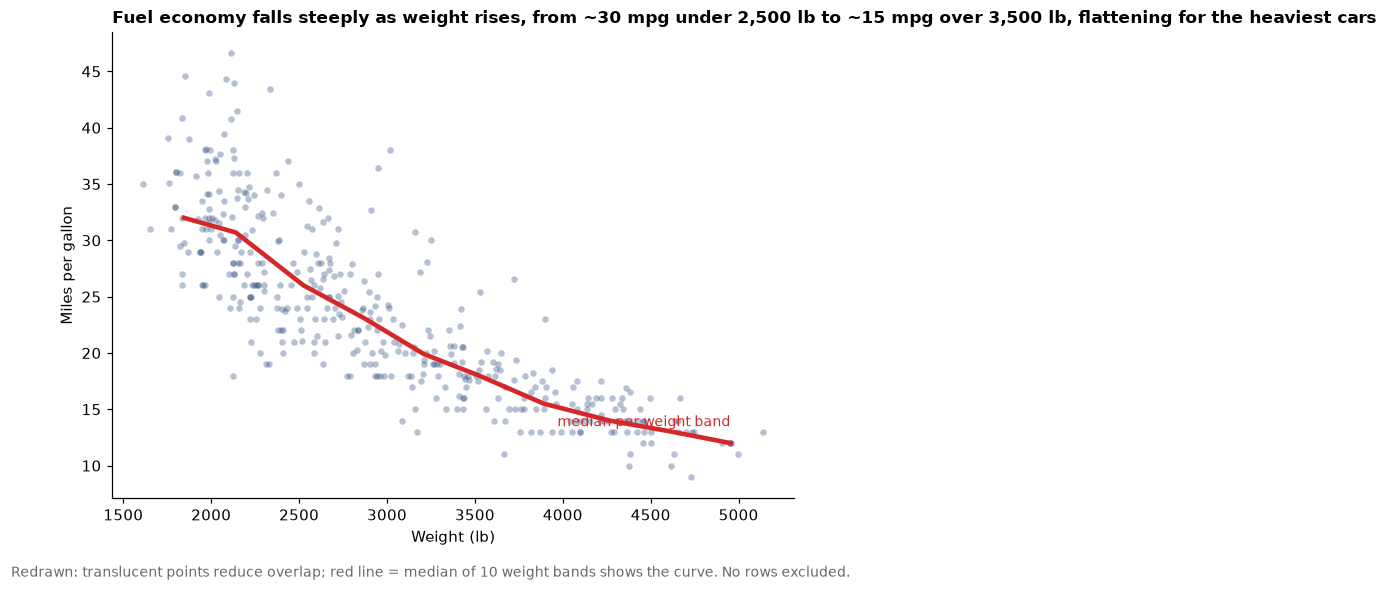

In [7]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(df.weight, df.mpg, s=18, alpha=0.35, color="#2b4c7e", linewidths=0)
bins = pd.cut(df.weight, 10); b = df.groupby(bins, observed=True).agg(w=("weight","median"), m=("mpg","median"))
ax.plot(b.w, b.m, color="#d62728", lw=3); ax.text(b.w.iloc[-1], b.m.iloc[-1]+1.5, "median per weight band", color="#d62728", ha="right", fontsize=9)
ax.set_xlabel("Weight (lb)"); ax.set_ylabel("Miles per gallon")
lo = df[df.weight < 2500].mpg.median(); hi = df[df.weight > 3500].mpg.median()
ax.set_title(f"Fuel economy falls steeply as weight rises, from ~{lo:.0f} mpg under 2,500 lb to ~{hi:.0f} mpg over 3,500 lb, flattening for the heaviest cars", fontsize=11)
NOTE(fig, "Redrawn: translucent points reduce overlap; red line = median of 10 weight bands shows the curve. No rows excluded."); plt.show()

**What I changed:** made points translucent and smaller (overlap), added a median-by-weight-band line (shows the curved trend), replaced the correlation-only title with the size of the effect, and added a note that no rows were excluded.